In [1]:
import os, random, numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs("artifacts", exist_ok=True)

Device: cuda


In [2]:
# Загрузка только train части
dataset = load_dataset("emotion", split="train")
labels = dataset.features['label'].names
print(f"Classes: {labels}")
print(f"Total samples: {len(dataset)}")

# Примеры
for i in range(3):
    idx = random.randint(0, len(dataset)-1)
    print(f"[{labels[dataset[idx]['label']]}]: {dataset[idx]['text'][:80]}...")

# Явное разделение: train 70% / val 10% / test 20%
dataset_temp = dataset.train_test_split(test_size=0.2, seed=SEED, stratify_by_column="label", shuffle=True)
dataset_final = dataset_temp["train"].train_test_split(test_size=0.125, seed=SEED, stratify_by_column="label", shuffle=True)

dataset = {
    "train": dataset_final["train"],
    "validation": dataset_final["test"],
    "test": dataset_temp["test"]
}

print(f"\nTrain: {len(dataset['train'])} | Val: {len(dataset['validation'])} | Test: {len(dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Total samples: 16000
[sadness]: i do find new friends i m going to try extra hard to make them stay and if i dec...
[joy]: i asked them to join me in creating a world where all year old girls could grow ...
[love]: i feel when you are a caring person you attract other caring people into your li...

Train: 11200 | Val: 1600 | Test: 3200


In [3]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

samples = ["I am happy!", "This is bad.", "Love it!"]
for text in samples:
    enc = tokenizer(text, padding='max_length', truncation=True, max_length=32)
    print(f"Text: {text}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'])[:10]}...")
    print(f"IDs: {enc['input_ids'][:10]} | Mask: {enc['attention_mask'][:10]}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text: I am happy!
Tokens: ['[CLS]', 'i', 'am', 'happy', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 1045, 2572, 3407, 999, 102, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Text: This is bad.
Tokens: ['[CLS]', 'this', 'is', 'bad', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 2023, 2003, 2919, 1012, 102, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
Text: Love it!
Tokens: ['[CLS]', 'love', 'it', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 2293, 2009, 999, 102, 0, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


In [4]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

samples = ["I am happy!", "This is bad.", "Love it!"]
for text in samples:
    enc = tokenizer(text, padding='max_length', truncation=True, max_length=32)
    print(f"Text: {text}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'])[:10]}...")
    print(f"IDs: {enc['input_ids'][:10]} | Mask: {enc['attention_mask'][:10]}")
    print("-" * 40)

Text: I am happy!
Tokens: ['[CLS]', 'i', 'am', 'happy', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 1045, 2572, 3407, 999, 102, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
----------------------------------------
Text: This is bad.
Tokens: ['[CLS]', 'this', 'is', 'bad', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 2023, 2003, 2919, 1012, 102, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
----------------------------------------
Text: Love it!
Tokens: ['[CLS]', 'love', 'it', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']...
IDs: [101, 2293, 2009, 999, 102, 0, 0, 0, 0, 0] | Mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
----------------------------------------


In [5]:
tokenized_dict = DatasetDict({
    "train": dataset["train"],
    "validation": dataset["validation"],
    "test": dataset["test"]
})

def tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized = tokenized_dict.map(tokenize, batched=True)
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(labels))
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="./results", eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16, per_device_eval_batch_size=64,
    num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
    metric_for_best_model="f1_macro", seed=SEED
)

trainer = Trainer(model=model, args=args, train_dataset=tokenized["train"],
                  eval_dataset=tokenized["validation"], processing_class =tokenizer, compute_metrics=compute_metrics)

print("Training...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.710778,0.263945,0.915625,0.882408
2,0.216609,0.209142,0.919375,0.886921
3,0.108674,0.200880,0.918125,0.880801


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2100, training_loss=0.287757500239781, metrics={'train_runtime': 236.4409, 'train_samples_per_second': 142.107, 'train_steps_per_second': 8.882, 'total_flos': 556402762137600.0, 'train_loss': 0.287757500239781, 'epoch': 3.0})

In [12]:
results = trainer.evaluate(tokenized["test"])
print(f"Test Results: {results}")

preds_out = trainer.predict(tokenized["test"])
preds = np.argmax(preds_out.predictions, axis=-1)
true_labels = preds_out.label_ids

acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="macro")
print(f"\nAccuracy: {acc:.4f} | F1 Macro: {f1:.4f}")

Test Results: {'eval_loss': 0.20463119447231293, 'eval_accuracy': 0.924375, 'eval_f1_macro': 0.8874488666704569, 'eval_runtime': 5.5187, 'eval_samples_per_second': 579.848, 'eval_steps_per_second': 9.06, 'epoch': 3.0}

Accuracy: 0.9244 | F1 Macro: 0.8874


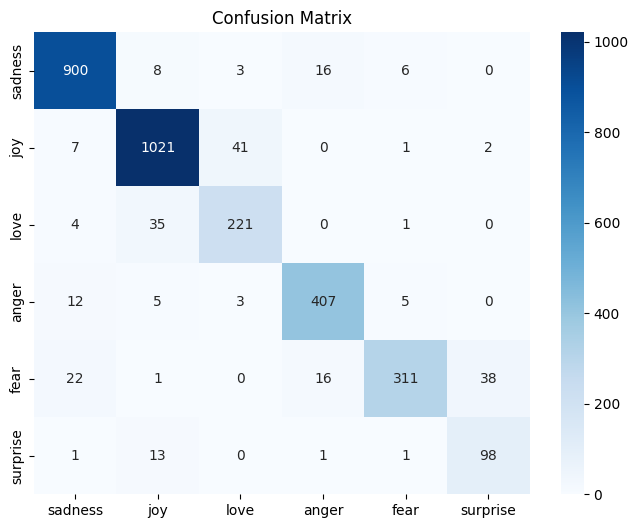

Artifacts saved to artifacts/


In [13]:
# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Sample Predictions CSV
errors_idx = [i for i in range(len(preds)) if preds[i] != true_labels[i]]
sample_idx = random.sample(range(len(preds)), min(100, len(preds)))

sample_data = []
for i in sample_idx:
    sample_data.append({
        "text": dataset["test"][i]["text"],
        "true_label": labels[true_labels[i]],
        "pred_label": labels[preds[i]],
        "confidence": float(np.max(preds_out.predictions[i]))
    })

pd.DataFrame(sample_data).to_csv("artifacts/sample_predictions.csv", index=False)
print("Artifacts saved to artifacts/")

In [14]:
print(f"Total errors: {len(errors_idx)} / {len(preds)}")
if errors_idx:
    print("\nError examples:")
    for i in errors_idx[:5]:
        print(f"Text: {dataset['test'][i]['text'][:60]}...")
        print(f"True: {labels[true_labels[i]]} | Pred: {labels[preds[i]]}\n")

Total errors: 242 / 3200

Error examples:
Text: i was intensely conscious of how much cash i had left in my ...
True: anger | Pred: sadness

Text: i feel like we just rushed around trying to see things its s...
True: anger | Pred: joy

Text: i heard it somehow it brings me good feeling strange...
True: fear | Pred: surprise

Text: i just feel like weve been living in a weird time warp like ...
True: fear | Pred: surprise

Text: i then asked as i often do in these situations how i could f...
True: sadness | Pred: anger

